## Study the following numerical illustration of the idea of the proof that any comparison-based algorithm for finding the maximum of n elements must use at least n-1 comparisons. Answer the questions that follow.

Connected Components:
{1, 2, 3}
{4, 5, 6}


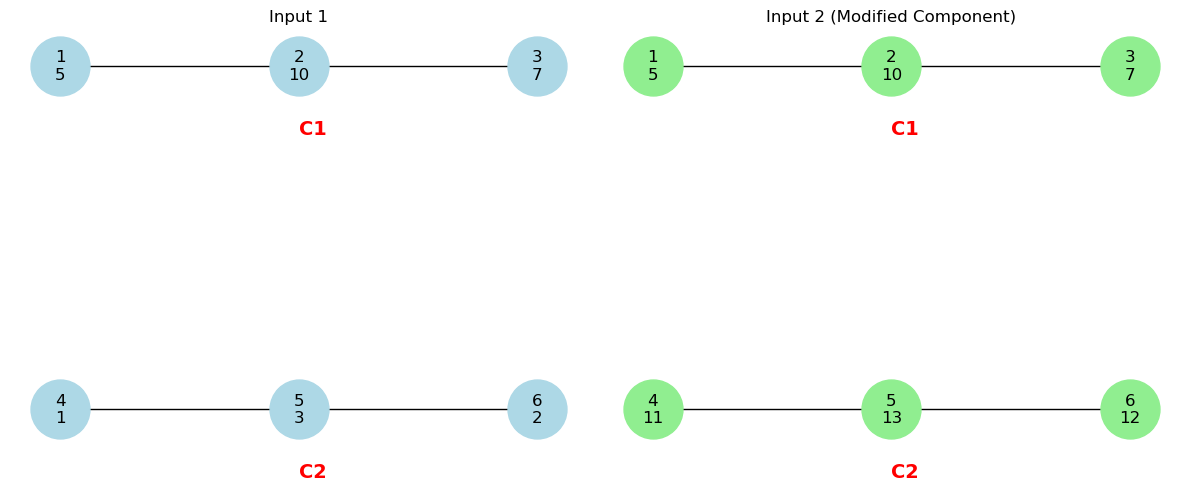

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

# ------------------------------------
# Comparison graph (< n-1 comparisons)
# ------------------------------------

G = nx.Graph()

# Component 1
G.add_edges_from([(1, 2), (2, 3)])

# Component 2
G.add_edges_from([(4, 5), (5, 6)])

components = list(nx.connected_components(G))

print("Connected Components:")
for c in components:
    print(c)

# ------------------------------------
# First input
# ------------------------------------

values1 = {
    1: 5,
    2: 10,   # algorithm declares this as maximum M
    3: 7,
    4: 1,
    5: 3,
    6: 2
}

# ------------------------------------
# Second input
# Increase every value in component 2
# ------------------------------------

values2 = {
    1: 5,
    2: 10,
    3: 7,
    4: 11,
    5: 13,
    6: 12
}

# ------------------------------------
# Draw both situations
# ------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pos = {
    1: (0, 1),
    2: (1, 1),
    3: (2, 1),
    4: (0, 0),
    5: (1, 0),
    6: (2, 0)
}

labels1 = {v: f"{v}\n{values1[v]}" for v in G.nodes()}
labels2 = {v: f"{v}\n{values2[v]}" for v in G.nodes()}

nx.draw(
    G, pos,
    node_color="lightblue",
    node_size=1800,
    ax=axes[0]
)
nx.draw_networkx_labels(G, pos, labels1, ax=axes[0])
axes[0].set_title("Input 1")



nx.draw(
    G, pos,
    node_color="lightgreen",
    node_size=1800,
    ax=axes[1]
)
nx.draw_networkx_labels(G, pos, labels2, ax=axes[1])
axes[1].set_title("Input 2 (Modified Component)")


for ax in axes:
    for i, C in enumerate(components, start=1):
        x = sum(pos[v][0] for v in C)/len(C)
        y = sum(pos[v][1] for v in C)/len(C)

        ax.text(
            x, y-0.2,
            f"C{i}",
            color="red",
            fontsize=14,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()


## Questions

1. Which component was modified?
2. Was any comparison performed between this component and the component containing M?
3. Why do comparison outcomes inside each component remain unchanged?
4. Why must the algorithm follow the same execution path?
5. The algorithm still reports M. Is M the true maximum in the modified input?
6. Explain the contradiction and conclude that at least n-1 comparisons are necessary.

## Answers:

1. Component C2 = {4, 5, 6} was modified.
2. No.
3. Inside C2, every value was increased by the same amount (10):
1→11,3→13,2→12.
Therefore, their relative ordering is unchanged:
1<3,1<2,2<3
becomes
11<13,11<12,12<13.
Similarly, C1 was not changed at all
4. A comparison-based algorithm chooses its next comparison based on the outcomes of previous comparisons. Since every comparison outcome is identical on the two inputs, the algorithm receives exactly the same information at every step. Consequently, it must make the same sequence of comparisons and follow the same execution path.
5. No. In the modified input, node with M is not the true maximum. The node 5 with value 13 in C2, is the true maximum. Algo never compared any element from C2 with M.
6. The contradiction is that the algorithm claims to find the maximum with fewer than n-1 comparisons. But with n-2 comparisons, the comparison graph has at least two connected components. One component contains the reported maximum M, and another component has all its values increased. M is not the true maximum.